Let $\vec{g} := (g_1,\dots,g_k)$ and $\vec{h} := (h_1,\dots, h_r)$. Then,
$$\textbf{num\_forb\_subs}(G, \vec{g}, \vec{h}) := \# \{ A \subset G \mid \exists g_i \not \in AA \text{ or } \exists h_j \not \in AA^{-1}   \}$$
<!-- $$ = \# \{ A \subset G \mid g_1 \not \in AA \lor \cdots \lor g_k \not \in AA \lor h_1 \not \in AA^{-1} \lor \cdots \lor h_r \not \in AA^{-1} \}$$
$$ = \sum_{A \subset G}\mathbb{1}_{AA}(g_1)\cdots\mathbb{1}_{AA}(g_k)\cdot \mathbb{1}_{AA^{-1}}(h_1) \cdots \mathbb{1}_{AA^{-1}}(h_r) $$ -->

In [1]:
from itertools import combinations
from tqdm.notebook import tqdm
import random
from collections import Counter
from sage.graphs.independent_sets import IndependentSets
from math import comb

In [2]:
# sub_less_half(n), bad_compute_mom(G,r), compute_true(G), compute_bals(G), nice(n), lucas(n)

def subs_less_half(n):
    M = n//2 + 1
    return sum(math.comb(n, r) for r in range(0, M))

def bad_compute_mom(G,r):
    elms = G.Elements()
    n = len(elms)
    M = n//2 + 1
    subs = (
        A
        for r in range(0, M)
        for A in combinations(elms, r)
    )
    total_subs = subs_less_half(n)
    tot = 0
    for A in tqdm(subs, total=total_subs):
        AA = len({g*h for g in A for h in A})
        A_invA = len({g*h.Inverse() for g in A for h in A})
        tot += (AA - A_invA)**r
    return tot

def compute_true(G):
    elms = G.Elements()
    n = len(elms)
    M = n//2 + 1
    subs = (
        A
        for r in range(0, M)
        for A in combinations(elms, r)
    )
    total_subs = subs_less_half(n)
    tot = 0
    for A in tqdm(subs, total=total_subs):
        AA = len({g*h for g in A for h in A})
        A_invA = len({g*h.Inverse() for g in A for h in A})
        diff = AA - A_invA
        if (AA > A_invA):
            tot += 1 
        elif (AA < A_invA):
            tot -= 1
    return tot


def compute_bals(G):
    elems = list(G)
    n = len(elems)
    index = {g: i for i, g in enumerate(elems)}
    mul = [
        [index[x * y] for y in elems]
        for x in elems
    ]

    div = [
        [index[x / y] for y in elems]
        for x in elems
    ]

    answer = sum(
        comb(n, j)
        for j in range(n//2 + 1, n + 1)
    )
    
    subs = (
    A
    for r in range(0, n//2 + 1)
    for A in combinations(range(n), r)
    )

    for A in tqdm(subs, total=subs_less_half(n)):
        AA = {
            mul[x][y]
            for x in A
            for y in A
        }
        AAh = {
            div[x][y]
            for x in A
            for y in A
        }
        if len(AA) == len(AAh):
            answer += 1
    return answer

def nice(n):
    return numerical_approx(n, digits=10)

def lucas(n):
    phi = (1+sqrt(5))/2
    return round(phi^n + (1-phi)^n)

In [3]:
# tuple_orbits(G, k), num_forb_subs(G, gs, hs), helper functions

def tuple_orbits(G, k):
    elements = G.Elements()
    aut_group = libgap.AutomorphismGroup(G)
    aut_order = aut_group.Order()
    tuple_orbits = []
    
    def build_orbits(current_stab, current_tuple):
        if len(current_tuple) == k:
            # Orbit-Stabilizer Theorem: |Orbit| = |G| / |Stabilizer|
            orbit_size = int(aut_order / current_stab.Order())
            tuple_orbits.append((current_tuple, orbit_size))
            return
        
        # Find the orbits of the current stabilizer acting on the group elements
        orbits = libgap.Orbits(current_stab, elements)
        
        for orb in orbits:
            rep = orb[0]
            
            # The new stabilizer is the subgroup of current_stab that also fixes 'rep'
            next_stab = libgap.Stabilizer(current_stab, rep)
            
            # Recurse deeper, adding this representative to our tuple
            build_orbits(next_stab, current_tuple + (rep,))
            
    build_orbits(aut_group, ())
    return tuple_orbits

class GroupContext:
    def __init__(self, G):
        """Precomputes the group structures for O(1) lookups."""
        # Convert G to libgap and extract elements
        self.G = libgap(G)
        self.elements = list(self.G.Elements())
        self.n = len(self.elements)
        
        # O(1) dictionary mapping a libgap element to its integer index
        self.elem_to_idx = {elem: i for i, elem in enumerate(self.elements)}
        
        # Precompute the Cayley Table (M) and Inverse Table (Inv)
        # M[i][j] gives the index of elements[i] * elements[j]
        self.M = [[0] * self.n for _ in range(self.n)]
        self.Inv = [0] * self.n
        
        for i, x in enumerate(self.elements):
            self.Inv[i] = self.elem_to_idx[x.Inverse()]
            for j, y in enumerate(self.elements):
                self.M[i][j] = self.elem_to_idx[x * y]
                
        # Precompute Fibonacci numbers (for path graphs)
        self.Fib = [0, 1, 1]
        for _ in range(self.n + 2): 
            self.Fib.append(self.Fib[-1] + self.Fib[-2])
            
        # Precompute Lucas numbers (for cycle graphs)
        self.Luc = [2, 1, 3] # L_0=2, L_1=1, L_2=3
        for _ in range(self.n): 
            self.Luc.append(self.Luc[-1] + self.Luc[-2])


def count_independent_sets_forbiddance_gh(ctx, S_conds):
    n = ctx.n
    adj = [set() for _ in range(n)]
    forbidden = set()

    # 1. Build the forbiddance graph using O(1) Cayley table lookups
    for cond_type, val in S_conds:
        val_idx = ctx.elem_to_idx[val]
        
        if cond_type == 'g':
            for i in range(n):
                # Right-neighbor: y = x^-1 * val
                j = ctx.M[ctx.Inv[i]][val_idx]
                if i == j: forbidden.add(i)
                else:
                    adj[i].add(j)
                    adj[j].add(i)
                    
                # Left-neighbor: y2 = val * x^-1
                j2 = ctx.M[val_idx][ctx.Inv[i]]
                if i == j2: forbidden.add(i)
                else:
                    adj[i].add(j2)
                    adj[j2].add(i)
                    
        elif cond_type == 'h':
            for i in range(n):
                # Role of x: y = h^-1 * x
                j = ctx.M[ctx.Inv[val_idx]][i]
                if i == j: forbidden.add(i)
                else:
                    adj[i].add(j)
                    adj[j].add(i)
                    
                # Role of y: x = h * y
                j2 = ctx.M[val_idx][i]
                if i == j2: forbidden.add(i)
                else:
                    adj[i].add(j2)
                    adj[j2].add(i)

    memo = {}

    # 2. Branch-and-reduce solver
    def solve(active_nodes):
        k = len(active_nodes)
        if k == 0: return 1

        # A. Quick DFS to extract exactly ONE connected component
        start_node = next(iter(active_nodes))
        comp = {start_node}
        stack = [start_node]
        
        while stack:
            curr = stack.pop()
            for nbr in adj[curr]:
                if nbr in active_nodes and nbr not in comp:
                    comp.add(nbr)
                    stack.append(nbr)

        # B. Divide and Conquer
        if len(comp) < k:
            return solve(frozenset(comp)) * solve(active_nodes - comp)

        # C. Memoization
        if active_nodes in memo:
            return memo[active_nodes]

        # D. Pivot Selection & Topological Short-Circuit
        deg_counts = {u: len(adj[u] & active_nodes) for u in active_nodes}
        max_deg = max(deg_counts.values())
        
        if max_deg <= 2:
            min_deg = min(deg_counts.values())
            if min_deg == 2:
                res = ctx.Luc[k]         # It's a cycle graph
            else:
                res = ctx.Fib[k + 2]     # It's a path graph
            
            memo[active_nodes] = res
            return res
            
        # E. Branch on highest degree vertex
        v = next(u for u, d in deg_counts.items() if d == max_deg)
        
        res_exclude = solve(active_nodes - {v})
        neighbors = adj[v] & active_nodes
        res_include = solve(active_nodes - {v} - neighbors)
        
        res = res_exclude + res_include
        memo[active_nodes] = res
        return res

    # 3. Start solver stripped of forbidden nodes
    initial_nodes = frozenset(set(range(n)) - forbidden)
    return solve(initial_nodes)


def num_forb_subs(G, gs, hs):
    ctx = GroupContext(G)
    # Dictionary from keys preserves insertion order while stripping duplicates
    unique_g = list(dict.fromkeys(gs))
    unique_h = list(dict.fromkeys(hs))
    
    conditions = [('g', g) for g in unique_g] + [('h', h) for h in unique_h]
    k_total = len(conditions)
    
    total_not_all = 0
    
    for m in range(1, k_total + 1):
        sign = (-1) ** (m - 1)
        for S_conds in combinations(conditions, m):
            i_FS = count_independent_sets_forbiddance_gh(ctx, S_conds)
            total_not_all += sign * i_FS
            
    return total_not_all

In [4]:
# compute_mom(G,r), bal_bound(G), var_bound(G), rand_grp(n), rand_lst(G, k), count_bals(G)

def compute_mom(G, r, verbatim=True):
    elms = G.Elements()
    n = len(elms)
    orbits = tuple_orbits(G, r)

    if verbatim:
        orbs = tqdm(orbits)
    else:
        orbs = orbits
    
    tot = 0
    for rep, orbit_size in orbs:
        val = 0
        for m in range(0, r+1):
            sgn = (-1)**(m+1)
            binom = binomial(r,m)

            split = r-m
            forbs = num_forb_subs(G, rep[:split], rep[split:])

            val += sgn*binom*forbs
            
        tot += orbit_size*val

    return tot

def bal_bound(G, verbatim=True):
    elms = G.Elements()
    n = len(elms)
    orbits = tuple_orbits(G, 1)
    if verbatim:
        orbs = tqdm(orbits)
    else:
        orbs = orbits

    tot = 0
    for rep, orbit_size in orbs:
        tot += orbit_size * num_forb_subs(G, rep, rep)
    return tot


def var_bound(G, verbatim=True):
    elms = G.Elements()
    n = len(elms)
    orbits = tuple_orbits(G, 1)
    if verbatim:
        orbs = tqdm(orbits)
    else:
        orbs = orbits

    tot = n * (n-1) * 19^(n/6)
    for rep, orbit_size in orbs:
        tot += orbit_size * (num_forb_subs(G, rep, []) + num_forb_subs(G, [], rep))
    return tot

def rand_grp(n):
    num_groups = libgap.NumberSmallGroups(n).sage()
    i = random.randint(1, num_groups)
    return libgap.SmallGroup(n,i)

def rand_lst(G, k):
    elms = G.Elements()
    combs = list(combinations(elms, k))
    return random.choice(combs)
    


In [16]:
# adj_matr(G,gs,hs), reg_matr(adj), split_matr(adj), show_graph(D), shortest_cycle_counts(G), upper_lucas(G, gs, hs):

def adj_matr(G, gs, hs):
    elms = G.Elements()
    n = G.Size().sage()
    matr = [[0 for _ in range(n)] for _ in range(n)]

    lookup = {g: i for i, g in enumerate(elms)}
    
    for i in range(n):
        x = elms[i]
        for g in gs:
            y = x.Inverse() * g
            ind = lookup[y]
            matr[i][ind] += 1
        for h in hs:
            y = h.Inverse() * x
            ind = lookup[y]
            matr[i][ind] += 1
    return matrix(QQbar, matr)

def to_one(adj, i, j):
    if adj[i][j] > 0 or adj[j][i] > 0:
        return 1
    else:
        return 0

def reg_matr(adj):
    n = adj.nrows()
    matr = [[to_one(adj,i,j) for j in range(n)] for i in range(n)]
    return matrix(QQbar, matr)

def split_matr(adj):
    n = adj.nrows()
    
    # Create an n x n zero matrix over the same base ring (e.g., ZZ or QQ)
    Z = matrix(adj.base_ring(), n, n, 0)
    
    # Assemble the 2n x 2n block matrix
    # [  0   A ]
    # [ A^T  0 ]
    B = block_matrix([
        [Z, adj],
        [adj.transpose(), Z]
    ])
    
    return B
    

def show_graph(D):
    D.plot(
        figsize=(10, 10),          # Increases the overall size of the plot
        vertex_size=20,          # Adjusts the size of the nodes
        vertex_color='lightblue', # Makes the nodes a more pleasant color
        edge_color='gray',        # Softens the edges
        edge_thickness=1.5,
        layout='spring',           # The default layout, but works better with more space
        iterations=1000,
        vertex_labels=True
        ).show()

def shortest_cycle_counts(D):

    dist = D.distance_all_pairs()
    
    lengths = []
    
    for v in D.vertices(sort=True):
        min_cycle = oo
        
        for w in D.neighbors_out(v):
            if v in dist[w]:
                min_cycle = min(min_cycle, 1 + dist[w][v])
                
        lengths.append(min_cycle)
        
    # Tally up the lengths and return as a standard dictionary
    return dict(Counter(lengths))

def upper_lucas(G, gs, hs):
    adj = adj_matr(G,gs,hs)
    D = DiGraph(adj)
    counts = shortest_cycle_counts(D)
    
    tot = 1
    for c in list(counts):
        num = counts[c]
        tot *= lucas(c)**(num/c)
    return tot

In [1169]:
def ult_equation(exp, var, theta, n):
    subs = subs_less_half(n)
    prop_subs = subs/(2**n)

    mu = exp/subs
    sig = var/subs - mu^2
    thing = sig/(sig + mu**2)
    bals = (theta + prop_subs - 1)/prop_subs
    first = thing - bals
    second = 1 - thing
    return nice(first), nice(second), sign(second-first)


def ult_equationv2(exp, var, theta, n):
    mu = exp/(2**n)
    sig = var/(2**n) - mu^2
    B = (theta)/(2**n)
    lhs = 2*(sig/(sig + mu**2))
    rhs = 1 + B
    return [nice(lhs), nice(rhs), nice(rhs-lhs), lhs<rhs]

def ult_equationv3(exp, var, theta, n):
    hlf = subs_less_half(n)
    mu = exp/hlf
    sig = var/hlf - mu^2
    B = (theta + hlf - 2**n)/hlf
    lhs = 2*(sig/(sig + mu**2))
    rhs = 1 + B
    return lhs, rhs, lhs<rhs

def ult_equationv4(exp, var, theta, n):
    mu = exp
    mu2 = var
    B = theta
    lhs = B
    rhs = 2*(mu^2)/mu2
    return [nice(lhs), nice(rhs), nice(rhs-lhs), bool(lhs<rhs)]


def ult_equationv5(exp, var, theta):
    val = 2*((exp)**2) / (var * theta)
    return nice(val), bool(val>1)

In [132]:
k = 27
G = libgap(DihedralGroup(k))
elms = G.Elements()
n = len(elms)


mom1 = compute_mom(G,1)
mom2 = compute_mom(G,2)
bals = bal_bound(G)

frc = (mom1**2) / (mom2 * bals)
show(nice(frc))

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/65 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

0.4908226200

In [164]:
L = 64
U = 64
rslts = [["Group", "Size", "2G", "Frac", "Success"]]
for N in tqdm(range(L, U+1)):
    amount = libgap.NumberSmallGroups(N)
    for i in range(1, amount+1):
        G = libgap.SmallGroup(N, i)
        if not G.IsAbelian():
            continue
        desc = G.StructureDescription().sage()
        m = len({g*g for g in G.Elements()})
        if m < 6:
            continue
        M1 = compute_mom(G, 1, True)
        M2 = compute_mom(G, 2, True)
        bals = bal_bound(G, True)
        if M1 == 0:
            frac = 0
        else:
            frac = (M1**2) / (M2 * bals)
        succ = (frac > 0.5)

        rslts.append([desc, N, m, nice(frac), succ])

show(table(rslts))
        

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/190 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

...

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/110 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

Group,Size,2G,Frac,Success
C64,\(64\),\(32\),\(0.5788129231\),\(\mathrm{True}\)
C8 x C8,\(64\),\(16\),\(0.5154288095\),\(\mathrm{True}\)
C16 x C4,\(64\),\(16\),\(0.5156433571\),\(\mathrm{True}\)
C32 x C2,\(64\),\(16\),\(0.5192318450\),\(\mathrm{True}\)
C4 x C4 x C4,\(64\),\(8\),\(0.4184887992\),\(\mathrm{False}\)
C8 x C4 x C2,\(64\),\(8\),\(0.4249135180\),\(\mathrm{False}\)
C16 x C2 x C2,\(64\),\(8\),\(0.4282014631\),\(\mathrm{False}\)


In [162]:
L = 100
U = 105
rslts = [["Group", "Size", "2G", "Frac", "Success"]]
for N in tqdm(range(L, U+1)):
    amount = libgap.NumberSmallGroups(N)
    for i in range(1, amount+1):
        G = libgap.SmallGroup(N, i)
        if not G.IsAbelian():
            continue
        desc = G.StructureDescription().sage()
        m = len({g*g for g in G.Elements()})
        if m < 6:
            continue
        M1 = compute_mom(G, 1, False)
        M2 = var_bound(G, False)
        bals = bal_bound(G, False)
        if M1 == 0:
            frac = 0
        else:
            frac = (M1**2) / (M2 * bals)
        succ = bool(frac > 0.5)

        rslts.append([desc, N, m, nice(frac), succ])

show(table(rslts))

  0%|          | 0/6 [00:00<?, ?it/s]

Group,Size,2G,Frac,Success
C100,\(100\),\(50\),\(0.6598940050\),\(\mathrm{True}\)
C50 x C2,\(100\),\(25\),\(0.6313491004\),\(\mathrm{True}\)
C20 x C5,\(100\),\(50\),\(0.6600153368\),\(\mathrm{True}\)
C10 x C10,\(100\),\(25\),\(0.6314490381\),\(\mathrm{True}\)
C101,\(101\),\(101\),\(0.6771049420\),\(\mathrm{True}\)
C102,\(102\),\(51\),\(0.6797654361\),\(\mathrm{True}\)
C103,\(103\),\(103\),\(0.6982661295\),\(\mathrm{True}\)
C104,\(104\),\(52\),\(0.6986832705\),\(\mathrm{True}\)
C52 x C2,\(104\),\(26\),\(0.6661200970\),\(\mathrm{True}\)
C26 x C2 x C2,\(104\),\(13\),\(0.5876060749\),\(\mathrm{True}\)


In [147]:
G = libgap(DihedralGroup(20))
bal_bound(G, False)

87853719838

In [113]:
def count_balanced_dihedral(k):
    G = DihedralGroup(k)
    elems = list(G)
    n = len(elems)
    index = {g: i for i, g in enumerate(elems)}
    mul = [
        [index[x * y] for y in elems]
        for x in elems
    ]

    div = [
        [index[x / y] for y in elems]
        for x in elems
    ]

    answer = sum(
        comb(n, k)
        for k in range(k + 1, n + 1)
    )

    for r in range(k+1):
        for s in range(k-r+1):
            for R in combinations(range(k), r):
                RR = {
                    mul[r1][r2]
                    for r1 in R
                    for r2 in R
                }
                RRh = {
                    div[r1][r2]
                    for r1 in R
                    for r2 in R
                }
                for S in combinations(range(k,n), s):
                    SS = {
                        mul[s1][s2]
                        for s1 in S
                        for s2 in S
                    }
                    RS = {
                        mul[r1][s1]
                        for r1 in R
                        for s1 in S
                    }
                    SR = {
                        mul[s1][r1]
                        for s1 in S
                        for r1 in R
                    }
                    if len(RR|SS|RS|SR) == len(RRh|SS|RS):
                        answer += 1
    return answer

In [114]:
import time
start_time = time.perf_counter()
res = count_balanced_dihedral(10)
end_time = time.perf_counter()
print(res)
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time:.6f} seconds")
# lst = list(G)
# for x in lst[:11]:
#     show(x^2)

806396
Elapsed time: 1.321164 seconds


  0%|          | 0/256 [00:00<?, ?it/s]

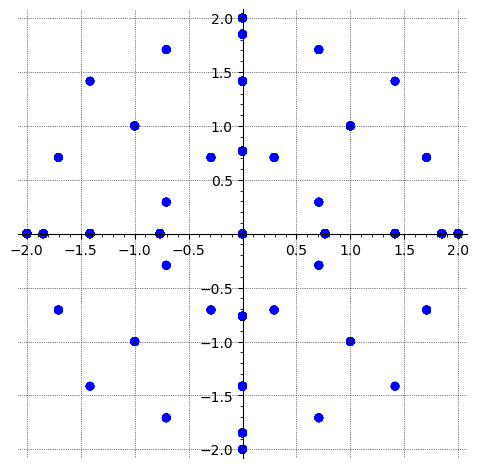

In [281]:
G_sage = DihedralGroup(8)
# G_sage = AlternatingGroup(4)
G = libgap(G_sage)
elms = G.Elements()
pnts = []
pnts_real = []

for (g1, g2) in tqdm(Tuples(elms, 2)):
# for g in elms:
    # print(f"Processing {(g1, g2)}")
    matr = adj_matr(G, [g1, g2], [])
    
    D = DiGraph(matr)
    # show_graph(D)
    # show(matr)
    poly = matr.charpoly()
    evals = [a for (a,b) in poly.roots(QQbar)]
    eval_pairs = [(val.real(), val.imag()) for val in evals]
    # rad_evals = [a.radical_expression() + I*b.radical_expression() for (a,b) in eval_pairs]
    pnts += eval_pairs
show(points(pnts, size=40, gridlines=True, aspect_ratio=1))

In [470]:
n = 40
G = rand_grp(n)
elms = G.Elements()
combs = combinations(elms, 2)

real_count = Counter()
imag_count = Counter()
for (g, h) in tqdm(combs, total=int(binomial(n,2))):
    adj = adj_matr(G, [g,h], [])
    evals = adj.eigenvalues(QQbar) 
    reals = [val.real() for val in evals]
    ims = [val.imag() for val in evals]
    real_count.update(reals)
    imag_count.update(ims)
    

  0%|          | 0/780 [00:00<?, ?it/s]

In [477]:
n=24
S = range(0, n)
mstd = 0
mdts = 0
bal = 0
for A in tqdm(subsets(S), total=int(2**n)):
    sm = len({x+y for x in A for y in A})
    df = len({x-y for x in A for y in A})
    if sm > df:
        mstd += 1
    elif sm < df:
        mdts += 1
    else:
        bal += 1
show(f"{numerical_approx(100*mstd/2^n)}%")
show(f"{numerical_approx(100*mdts/2^n)}%")
show(f"{numerical_approx(100*bal/2^n)}%")

  0%|          | 0/16777216 [00:00<?, ?it/s]

'0.0380754470825195%'

'91.1044955253601%'

'8.85742902755737%'